# MUSIC DOA Estimation

MUSIC is a high-resolution DOA estimator. Instead of forming beamformer weights, it uses the covariance matrix eigenvectors to separate signal and noise subspaces.

## Math

MUSIC follows PySDR's subspace convention: compute the covariance matrix $R$, eigendecompose it, keep the noise-subspace eigenvectors in $V_n$, then scan steering vectors $s$.

$$
R = V_s \Lambda_s V_s^H + V_n \Lambda_n V_n^H
$$

At true source angles, $s$ is nearly orthogonal to the noise subspace. The PySDR MUSIC metric is:

$$
\hat{\theta} = \arg\max_\theta \frac{1}{s^H V_n V_n^H s}
$$

The peaks of this pseudospectrum are the DOA estimates.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True


In [2]:
def steering_vector(Nr, d, theta_deg):
    """PySDR-style ULA steering vector. d is measured in wavelengths."""
    theta = np.deg2rad(theta_deg)
    k = np.arange(Nr).reshape(-1, 1)
    s = np.exp(2j * np.pi * d * k * np.sin(theta))
    return s


def complex_noise(shape, rng, power=1.0):
    """Circular complex Gaussian noise with E{|n|^2}=power."""
    return np.sqrt(power / 2) * (
        rng.standard_normal(shape) + 1j * rng.standard_normal(shape)
    )


def simulate_snapshots(Nr, d, thetas_deg, N, source_powers=None, snr_db=20, seed=0):
    """Simulate narrowband far-field snapshots for a ULA.

    Returns X with shape Nr x N, matching the PySDR convention.
    """
    rng = np.random.default_rng(seed)
    thetas_deg = np.asarray(thetas_deg, dtype=float)
    if source_powers is None:
        source_powers = np.ones(len(thetas_deg))
    source_powers = np.asarray(source_powers, dtype=float)

    S_theta = np.hstack([steering_vector(Nr, d, theta) for theta in thetas_deg])
    signals = complex_noise((len(thetas_deg), N), rng)
    signals *= np.sqrt(source_powers).reshape(-1, 1)
    X = S_theta @ signals

    if snr_db is not None:
        signal_power = np.mean(np.abs(X) ** 2)
        noise_power = signal_power / (10 ** (snr_db / 10))
        X = X + complex_noise(X.shape, rng, noise_power)

    return X, S_theta, signals


def sample_covariance(X):
    """Estimate R = (X @ X.conj().T) / N."""
    return (X @ X.conj().T) / X.shape[1]


def to_db(power, floor_db=-80):
    power = np.asarray(power, dtype=float)
    peak = np.max(power)
    floor = peak * (10 ** (floor_db / 10))
    return 10 * np.log10(np.maximum(power, floor) / peak)


def top_k_peaks(angles, spectrum_db, k, min_separation_degrees=3):
    maxima = np.flatnonzero(
        (spectrum_db[1:-1] >= spectrum_db[:-2]) &
        (spectrum_db[1:-1] >= spectrum_db[2:])
    ) + 1
    ranked = maxima[np.argsort(spectrum_db[maxima])[::-1]]
    selected = []
    for idx in ranked:
        if all(abs(angles[idx] - angles[old]) >= min_separation_degrees
               for old in selected):
            selected.append(idx)
        if len(selected) == k:
            break
    return [(float(angles[idx]), float(spectrum_db[idx])) for idx in selected]


In [3]:
Nr = 10
d = 0.5
true_thetas = [-25, 35]
num_expected_signals = len(true_thetas)

X, S_theta, signals = simulate_snapshots(
    Nr,
    d,
    true_thetas,
    N=4096,
    snr_db=15,
    seed=3,
)
R = sample_covariance(X)

eigenvalues, eigenvectors = np.linalg.eig(R)
order = np.argsort(np.abs(eigenvalues))[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

Vn = eigenvectors[:, num_expected_signals:]
print("Descending covariance eigenvalues:")
print(np.round(np.abs(eigenvalues), 3))


Descending covariance eigenvalues:
[10.048  9.85   0.067  0.065  0.064  0.063  0.062  0.061  0.06   0.059]


Estimated DOAs: [-25.0, 35.0]


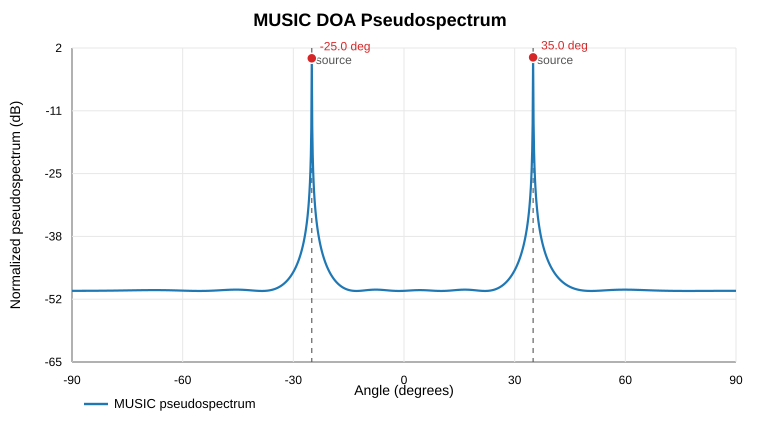

In [4]:
scan_angles = np.linspace(-90, 90, 1441)
pseudospectrum = []

for theta in scan_angles:
    s = steering_vector(Nr, d, theta)
    metric = 1 / (s.conj().T @ Vn @ Vn.conj().T @ s)
    pseudospectrum.append(np.abs(metric.squeeze()))

music_db = to_db(pseudospectrum)
peaks = top_k_peaks(scan_angles, music_db, num_expected_signals)
estimated_thetas = sorted(round(theta, 1) for theta, level in peaks)
print("Estimated DOAs:", estimated_thetas)

plt.plot(scan_angles, music_db)
for theta in true_thetas:
    plt.axvline(theta, color="k", linestyle="--", alpha=0.5)
for theta, level in peaks:
    plt.plot(theta, level, "ro")
plt.xlabel("Angle (degrees)")
plt.ylabel("Normalized pseudospectrum (dB)")
plt.title("MUSIC DOA Pseudospectrum")
plt.ylim(-65, 2)
plt.show()


## What to notice

MUSIC produces very sharp peaks when the source count is correct and the covariance estimate is good. In practice, coherent sources, too few snapshots, or a wrong source count can degrade the estimate.